In [21]:
import pennylane as qml

#BASIS ENCODING
dev = qml.device("default.qubit", range(3))
@qml.qnode(dev)
def circuit(x):
    qml.BasisEmbedding(x, range(3))
    return qml.state()

circuit(6)

array([0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j])

In [22]:
import pennylane as qml
import numpy as np

#AMPLITUDE ENCODING
n_qubits = 8
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev)
def circuit(x):
    qml.AmplitudeEmbedding(features=x, wires=range(n_qubits), normalize=True, pad_with=0.)
    return(qml.state())

x_real = np.random.normal(loc=0, scale=1.0, size=2**n_qubits)
x_imag = np.random.normal(loc=0, scale=1.0, size=2**n_qubits)
x = x_real + 1j * x_imag

circuit(x)

array([ 2.20383740e-03-3.97607218e-02j,  4.25465501e-02+2.35670418e-03j,
        2.16609052e-03-2.06951238e-02j, -6.02637863e-02+4.57143580e-02j,
       -9.80962571e-02-5.48612410e-02j,  3.48954981e-03+1.82190900e-02j,
       -2.31338554e-02+2.45829357e-02j,  1.09561066e-01-4.12502090e-03j,
       -4.69858135e-02-2.76237564e-02j, -5.76058081e-02+6.35274113e-02j,
       -2.50706303e-02-3.01644788e-02j,  7.32250807e-02+1.05836241e-01j,
       -2.78722648e-02-1.48967338e-02j,  4.53285821e-02+3.71803420e-02j,
       -8.93516105e-02+5.18839653e-02j, -3.33678507e-02+1.03530268e-02j,
       -6.40693607e-02+2.59982409e-02j, -7.70398259e-03+1.72992049e-02j,
       -3.81636254e-02-4.32198126e-02j, -3.66605680e-02-3.54735791e-02j,
       -3.46575967e-02-9.32916965e-02j, -2.72516286e-02-6.60918871e-02j,
       -5.97595746e-02-7.07930503e-02j, -2.80221013e-02-1.30646970e-02j,
       -5.50255431e-02-2.87173565e-02j,  9.29727128e-02-1.48714601e-04j,
        1.53954368e-03+1.72500400e-02j, -1.40644681

In [23]:
import pennylane as qml
import numpy as np

#ANGLE ENCODING
n_qubits = 8

dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev)
def circuit(x):
    qml.AngleEmbedding(features=x, wires=range(n_qubits), rotation="X")
    return(qml.state())

x = np.random.uniform(0, np.pi, (n_qubits))

circuit(x)

array([ 3.59422528e-04+0.00000000e+00j,  0.00000000e+00-1.54035368e-04j,
        0.00000000e+00-7.77220548e-04j, -3.33088339e-04+0.00000000e+00j,
        0.00000000e+00-6.24942850e-04j, -2.67827680e-04+0.00000000e+00j,
       -1.35138559e-03+0.00000000e+00j,  0.00000000e+00+5.79154504e-04j,
        0.00000000e+00-1.17619195e-04j, -5.04072908e-05+0.00000000e+00j,
       -2.54341472e-04+0.00000000e+00j,  0.00000000e+00+1.09001465e-04j,
       -2.04509370e-04+0.00000000e+00j,  0.00000000e+00+8.76452463e-05j,
        0.00000000e+00+4.42234063e-04j,  1.89525367e-04+0.00000000e+00j,
        0.00000000e+00-5.86698726e-04j, -2.51437645e-04+0.00000000e+00j,
       -1.26868593e-03+0.00000000e+00j,  0.00000000e+00+5.43712453e-04j,
       -1.02011740e-03+0.00000000e+00j,  0.00000000e+00+4.37185057e-04j,
        0.00000000e+00+2.20591683e-03j,  9.45375383e-04+0.00000000e+00j,
       -1.91994175e-04+0.00000000e+00j,  0.00000000e+00+8.22816908e-05j,
        0.00000000e+00+4.15171021e-04j,  1.77927136

[ 0.36+0.j  0.  +0.j  0.  +0.j  0.64+0.j -0.48+0.j  0.  +0.j  0.  +0.j
  0.48+0.j]
Post-selected state: [0.36+0.j 0.  +0.j 0.  +0.j 0.64+0.j]
Norm: 0.7343023900274328
Normalized result: [0.4903+0.j 0.    +0.j 0.    +0.j 0.8716+0.j]


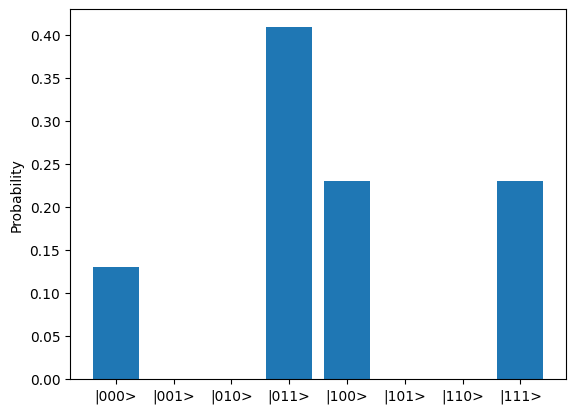

In [24]:
import numpy as np
import pennylane as qml
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

a = 0.36
b = 0.64

A = np.array(
    [[a,  0, 0,  b],
     [0, -a, b,  0],
     [0,  b, a,  0],
     [b,  0, 0, -a]]
)

LCU = qml.pauli_decompose(A)
LCU_coeffs, LCU_ops = LCU.terms()

alphas = (np.sqrt(LCU_coeffs) / np.linalg.norm(np.sqrt(LCU_coeffs)))

dev = qml.device("default.qubit", wires=3)

ops = LCU_ops
unitaries = [qml.map_wires(op, {0: 1, 1: 2}) for op in ops]

@qml.qnode(dev)
def lcu_circuit():
    qml.StatePrep(alphas, wires=0)
    qml.Select(unitaries, control=0)
    qml.adjoint(qml.StatePrep(alphas, wires=0))
    return(qml.state())

state = lcu_circuit()
print(state)

# Reshape into (ancilla, target_system)
# qubit 0 is ancilla, qubits 1-2 are target
state_matrix = state.reshape(2, 4)  # 2 ancilla states, 4 target states

# Post-select: keep only ancilla = |0> part
post_selected = state_matrix[0]

print("Post-selected state:", post_selected)
print("Norm:", np.linalg.norm(post_selected))

# Normalize
result = post_selected / np.linalg.norm(post_selected)
print("Normalized result:", np.round(result, 4))
#print(np.real(np.round(output_matrix,2)))

probs = np.abs(state)**2
labels = [f'|{i:03b}>' for i in range(8)]
plt.bar(labels, probs)
plt.ylabel('Probability')
plt.show()

In [25]:
n_layers = 2
n_qubits = 4
dev = qml.device("default.qubit", wires=n_qubits)

a = 0.36
b = 0.64

B = np.array(
    [[a,  0, 0,  b],
     [0, -a, b,  0],
     [0,  b, a,  0],
     [b,  0, 0, -a]]
)

weights_shape = qml.StronglyEntanglingLayers.shape(n_layers=n_layers, n_wires=n_qubits)
weights = np.random.uniform(0, np.pi, weights_shape)

x = np.random.uniform(0, np.pi, n_qubits)

@qml.qnode(dev)
def full_pipeline(x, weights):
    qml.AngleEmbedding(x, wires=range(n_qubits), rotation="Y")
    qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
    return qml.expval(qml.PauliZ(0))

print(full_pipeline(x, weights))

-0.025588476608013777


In [27]:
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from pennylane.optimize import AdamOptimizer
from pennylane import numpy as pnp

data = load_breast_cancer()
X = data.data
y = data.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=4)
X_pca = pca.fit_transform(X_scaled)

X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape)
print(X_test.shape)

def square_loss(labels, predictions):
    return np.mean((labels - predictions) ** 2)

label = 1.0
prediction = 0.40
print(square_loss(label, prediction))

opt = AdamOptimizer(stepsize=0.1)
weights = pnp.random.uniform(0, pnp.pi, weights_shape, requires_grad=True)
bias = pnp.array(0.0, requires_grad=True)

print(weights.shape)
print(bias)

def classifier(weights, bias, x):
    return full_pipeline(x, weights) + bias

def cost(weights, bias, X, y):
    preds = [classifier(weights, bias, x) for x in X]
    labels = 2 * y - 1
    return square_loss(labels, pnp.array(preds))

X_sample = pnp.array(X_train[:5], requires_grad=False)
y_sample = pnp.array(y_train[:5], requires_grad=False)
print(cost(weights, bias, X_sample, y_sample))

(455, 4)
(114, 4)
0.36
(2, 4, 3)
0.0
0.98747975636696
